In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('./Divar.csv')
data.head()

C:\Users\DANA-RAYANEH\AppData\Local\Temp\ipykernel_11856\634558926.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./Divar.csv')


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div dir="rtl">

ما تو این بخش مسئولیت انجام <span dir="ltr">PreProcessing</span> تو ستون‌های: <span dir="ltr">has_balcony</span>, <span dir="ltr">has_elevator</span>, <span dir="ltr">has_warehouse</span>, <span dir="ltr">has_parking</span>, <span dir="ltr">has_water</span>, <span dir="ltr">has_electricity</span>, <span dir="ltr">has_gas</span>, <span dir="ltr">has_warm_water_provider</span>, <span dir="ltr">has_heating_system</span>, <span dir="ltr">has_cooling_system</span>, <span dir="ltr">has_restroom</span>, <span dir="ltr">has_security_guard</span>, <span dir="ltr">has_barbecue</span>, <span dir="ltr">has_pool</span>, <span dir="ltr">has_jacuzzi</span>, <span dir="ltr">has_sauna</span>, <span dir="ltr">floor_material</span>, <span dir="ltr">building_direction</span> رو داشتیم.
برای این کار ابتدا ستون‌هایی که مقادیر <span dir="ltr">Boolean</span> میپذیرفتن و امکان داشت از طریق ستون <span dir="ltr">description</span> بتونیم مقادیرشون رو پیدا کنیم جدا کردیم و جستجو رو انجام دادیم.

</div>

In [3]:
desc = data['description'].fillna('')

features = {
    'pool': 'استخر',
    'jacuzzi': 'جکوزی',
    'sauna': 'سونا',
    'balcony': 'بالکن',
    'elevator': 'آسانسور',
    'parking': 'پارکینگ',
    'security_guard': 'نگهبان',
    'barbecue': 'باربیکیو',
    'warehouse': 'انباری'
}

for col in features:
    data[f'PreP_has_{col}'] = data[f'has_{col}']

for col, keyword in features.items():
    mask = data[f'PreP_has_{col}'].ne(False) #گفتم برابر فالس نیست چون فرض رو بر این گذاشتم که تیکی که زدن درست‌تر از وجود صرفا یه کی‌ورد هست
    data.loc[mask & desc.str.contains(keyword, na=False), f'PreP_has_{col}'] = True
    data.loc[mask & desc.str.contains(f'{keyword} ندارد', na=False), f'PreP_has_{col}'] = False
    data.loc[mask & desc.str.contains(f'{keyword} نداره', na=False), f'PreP_has_{col}'] = False
    data.loc[mask & desc.str.contains(f'فاقد {keyword}', na=False), f'PreP_has_{col}'] = False

<div dir="rtl">
تفاوت قبل و بعد <span dir="ltr">Missing value</span> ها در اثر <span dir="ltr">PreProcessing</span>
</div>

In [4]:
check = pd.DataFrame()

for col in features:
    check[f'PreP_has_{col}'] = data[f'PreP_has_{col}']
    check[f'has_{col}'] = data[f'has_{col}']

nan_report = pd.DataFrame({
    'column': check.columns,
    'nan_percent': check.isna().mean().values * 100,
    'unique_values': [
        check[c].value_counts(dropna=False).to_dict()
        for c in check.columns
    ]
})

nan_report


,column,nan_percent,unique_values
0,PreP_has_pool,93.6894,"{nan: 936894, True: 37410, False: 25696}"
1,has_pool,97.0610,"{nan: 970610, False: 25669, True: 3721}"
2,PreP_has_jacuzzi,95.6928,"{nan: 956928, False: 26456, True: 16616}"
3,has_jacuzzi,97.1272,"{nan: 971272, False: 26455, True: 2273}"
4,PreP_has_sauna,96.1592,"{nan: 961592, False: 27087, True: 11321}"
5,has_sauna,97.1521,"{nan: 971521, False: 27084, True: 1395}"
6,PreP_has_balcony,46.6524,"{nan: 466524, 'true': 335390, True: 104848, 'f..."
7,has_balcony,49.3589,"{nan: 493589, 'true': 392096, 'false': 88855, ..."
8,PreP_has_elevator,45.2592,"{nan: 452592, True: 370633, False: 176775}"
9,has_elevator,45.8251,"{nan: 458251, True: 365148, False: 176601}"


<div dir="rtl">
روش دستی چک کردن :))
</div>

In [5]:
data[data['description'].str.contains('گرمایش')].iloc[500,7]

'آپارتمان ۱۵۰ متری\nفول امکانات\n مرکز الهیه \nطبقه ششم بدون مشرف\nکوریدور دو واحدی\nنورگیر عالی\nسه خواب دو خواب نورگیر یه خواب مستر\nبالکن بزرگ کاربردی \nکف سرامیک \nآشپزخانه بزرگ با کابینت نئوکلاسیک\nگرمایش شوفاژ سرمایش کولر گازی\nتحویل سه ماه دیگه\n\n\n ⚜️⚜️قابل معاوضه با واحد کوچکتر یا ماشین⚜️⚜️ ⚜️⚜️⚜️⚜️⚜️ با قیمت مناسب ⚜️⚜️⚜️⚜️⚜️⚜️\n\n\n   تخفیف ویژه برای خریدار نقدی \n\nمشاورین املاک چشم انداز نبش الهیه 40\nمشاور شما : قدمگاهی'

<div dir="rtl">
حالا میایم و مقادیر موجود تو ستون‌هایی که مقادیر <span dir="ltr">boolean</span> نمیپذیرن چک کنیم.
</div>

In [6]:
cols = ['has_warm_water_provider',
    'has_heating_system',
    'has_restroom',    
    'floor_material',
    'building_direction',
    'has_cooling_system']
for i in cols:
    print(i, data[i].dropna().unique())

has_warm_water_provider ['package' 'water_heater' 'powerhouse' 'unselect']
has_heating_system ['shoofaj' 'duct_split' 'heater' 'split' 'fireplace' 'unselect'
 'floor_heating' 'fan_coil']
has_restroom ['squat_seat' 'squat' 'seat' 'unselect']
floor_material ['ceramic' 'carpet' 'wood_parquet' 'stone' 'mosaic' 'laminate_parquet'
 'floor_covering' 'unselect']
building_direction ['north' 'south' 'east' 'west' 'unselect']
has_cooling_system ['air_conditioner' 'water_cooler' 'duct_split' 'split' 'unselect'
 'fan_coil']


<div dir="rtl">
الان میتونیم همون عملیات جستجو توی ستون <span dir="ltr">description</span> که قبلا انجام داده بودیم برای ستون‌هایی که مقادیر <span dir="ltr">boolean</span> داشتن رو برای ستون‌های دیگه که قابل استخراج هست، انجام بدیم.
</div>

In [7]:
keyword_map = {
    'has_heating_system': {
        'shoofaj': ['شوفاژ'],
        'duct_split': ['داکت اسپلیت', 'داکت‌اسپلیت', 'داکت'],
        'heater': ['بخاری' , 'هیتر'],
        'split': ['اسپلیت'],
        'fireplace': ['شومینه'],
        'floor_heating': ['گرمایش از کف', 'کف گرمایشی', 'کف‌گرمایشی'],
        'fan_coil': ['فن کویل', 'فن‌کویل']
    },

    'has_cooling_system': {
        'air_conditioner': ['کولر گازی', 'کولرگازی'],
        'water_cooler': ['کولر آبی', 'کولرآبی'],
        'duct_split': ['داکت اسپلیت', 'داکت‌اسپلیت', 'داکت'],
        'split': ['اسپلیت'],
        'fan_coil': ['فن کویل', 'فن‌کویل']
    },

    'has_warm_water_provider': {
        'package': ['پکیج'],
        'water_heater': ['آبگرمکن', 'آب گرمکن'],
        'powerhouse': ['موتورخانه']
    }
}

for col in keyword_map:
    data[f'PreP_{col}'] = data[col].replace('unselect', np.nan)

data['PreP_has_restroom'] = data['has_restroom'].replace('unselect', np.nan)

def is_negated(desc, keyword):
    return (
        desc.str.contains(f'{keyword} ندارد', regex=False, na=False) |
        desc.str.contains(f'{keyword} نداره', regex=False, na=False) |
        desc.str.contains(f'فاقد {keyword}', regex=False, na=False) |
        desc.str.contains(f'بدون {keyword}', regex=False, na=False)
    )

def fill_from_description(df, prep_col, keywords_dict):
    desc = df['description'].fillna('')
    missing = df[prep_col].isna() #توی ستون مورد نظر، مقادیری که پر نشدن هدف بررسیمونه. پس میشه یه بولین سریز
    for value, keywords in keywords_dict.items():
        found = pd.Series(False, index=df.index)
        for kw in keywords:
            kw_found = desc.str.contains(kw, regex=False, na=False)
            kw_negated = is_negated(desc, kw)
            found = found | (kw_found & ~kw_negated)
        df.loc[missing & found, prep_col] = value

for col, keywords in keyword_map.items():
    fill_from_description(data, f'PreP_{col}', keywords)

has_squat = desc.str.contains('ایرانی', regex=False, na=False)
has_seat = desc.str.contains('فرنگی', regex=False, na=False)
missing = data['PreP_has_restroom'].isna()

data.loc[missing & has_squat & has_seat, 'PreP_has_restroom'] = 'squat_seat'
data.loc[missing & has_squat & ~has_seat, 'PreP_has_restroom'] = 'squat'
data.loc[missing & has_seat & ~has_squat, 'PreP_has_restroom'] = 'seat'


<div dir="rtl">
تفاوت قبل و بعد مقدار <span dir="ltr">Missing Value</span> های ستون‌های مرحله‌ی قبل بعد از انجام <span dir="ltr">PreProcessing</span>
</div>

In [8]:
check2 = pd.DataFrame()

for col in keyword_map:
    check2[f'PreP_{col}'] = data[f'PreP_{col}']
    check2[col] = data[col]

nan_report2 = pd.DataFrame({
    'column': check2.columns,
    'nan_percent': check2.isna().mean().values * 100,
    'unique_values': [
        check2[c].value_counts(dropna=False).to_dict()
        for c in check2.columns
    ]
})
nan_report2

,column,nan_percent,unique_values
0,PreP_has_heating_system,61.8674,"{nan: 618674, 'shoofaj': 205397, 'heater': 123..."
1,has_heating_system,63.1031,"{nan: 631031, 'shoofaj': 201356, 'heater': 119..."
2,PreP_has_cooling_system,63.5925,"{nan: 635925, 'water_cooler': 225503, 'air_con..."
3,has_cooling_system,64.9381,"{nan: 649381, 'water_cooler': 219266, 'air_con..."
4,PreP_has_warm_water_provider,59.4691,"{nan: 594691, 'package': 228782, 'water_heater..."
5,has_warm_water_provider,62.0500,"{nan: 620500, 'package': 205641, 'water_heater..."


<div dir="rtl">
جدا کردن کامل ستون‌هایی که برای من بود.
</div>

In [9]:
PartK = pd.DataFrame(data,
    columns=[
    'PreP_has_warm_water_provider',
    'PreP_has_heating_system',
    'PreP_has_restroom',    
    'floor_material',
    'building_direction',
    'PreP_has_cooling_system',
    'has_water',
    'has_electricity',
    'has_gas',
    'PreP_has_pool', 
    'PreP_has_jacuzzi', 
    'PreP_has_sauna', 
    'PreP_has_balcony', 
    'PreP_has_elevator', 
    'PreP_has_parking', 
    'PreP_has_security_guard' , 
    'PreP_has_barbecue',
    'PreP_has_warehouse'
    ]
)

In [10]:
PartK

,PreP_has_warm_water_provider,PreP_has_heating_system,PreP_has_restroom,floor_material,building_direction,PreP_has_cooling_system,has_water,has_electricity,has_gas,PreP_has_pool,PreP_has_jacuzzi,PreP_has_sauna,PreP_has_balcony,PreP_has_elevator,PreP_has_parking,PreP_has_security_guard,PreP_has_barbecue,PreP_has_warehouse
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False
4,package,shoofaj,squat_seat,ceramic,north,air_conditioner,NaN,NaN,NaN,NaN,NaN,NaN,true,True,True,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
999996,NaN,NaN,seat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
999997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,True,NaN,NaN,True
999998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
PartK.info()
# همه آبجکت هستن :))))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   PreP_has_warm_water_provider  405309 non-null  object
 1   PreP_has_heating_system       381326 non-null  object
 2   PreP_has_restroom             423227 non-null  object
 3   floor_material                405984 non-null  object
 4   building_direction            323923 non-null  object
 5   PreP_has_cooling_system       364075 non-null  object
 6   has_water                     33444 non-null   object
 7   has_electricity               33445 non-null   object
 8   has_gas                       33430 non-null   object
 9   PreP_has_pool                 63106 non-null   object
 10  PreP_has_jacuzzi              43072 non-null   object
 11  PreP_has_sauna                38408 non-null   object
 12  PreP_has_balcony              533476 non-null  object
 13

In [12]:
nan_report = pd.DataFrame({
    'column': PartK.columns,
    'nan_count': PartK.isna().sum(),
    'nan_percent': PartK.isna().mean() * 100
}).sort_values('nan_percent', ascending=False)
nan_report

,column,nan_count,nan_percent
has_gas,has_gas,966570,96.6570
has_water,has_water,966556,96.6556
has_electricity,has_electricity,966555,96.6555
PreP_has_barbecue,PreP_has_barbecue,961975,96.1975
PreP_has_sauna,PreP_has_sauna,961592,96.1592
PreP_has_jacuzzi,PreP_has_jacuzzi,956928,95.6928
PreP_has_pool,PreP_has_pool,936894,93.6894
PreP_has_security_guard,PreP_has_security_guard,932840,93.2840
building_direction,building_direction,676077,67.6077
PreP_has_cooling_system,PreP_has_cooling_system,635925,63.5925


<div dir="rtl">
دیتا‌هایی که مقادیر <span dir="ltr">boolean</span> داشتن رو جدا کردیم تا بتونیم بررسی بهتری انجام بدیم.
</div>

In [13]:
PartK_TF = PartK.copy()
PartK_TF = pd.DataFrame(PartK_TF, columns= [
    'has_water',
    'has_electricity',
    'has_gas',
    'PreP_has_pool', 
    'PreP_has_jacuzzi', 
    'PreP_has_sauna', 
    'PreP_has_balcony', 
    'PreP_has_elevator', 
    'PreP_has_parking', 
    'PreP_has_security_guard' , 
    'PreP_has_barbecue',
    'PreP_has_warehouse'
])
PartK_TF

,has_water,has_electricity,has_gas,PreP_has_pool,PreP_has_jacuzzi,PreP_has_sauna,PreP_has_balcony,PreP_has_elevator,PreP_has_parking,PreP_has_security_guard,PreP_has_barbecue,PreP_has_warehouse
0,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,False
4,NaN,NaN,NaN,NaN,NaN,NaN,true,True,True,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
999996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,True
999997,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,True,NaN,NaN,True
999998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div dir="rtl">
اول چک میکنیم مطمئن شیم همه مقادیر واقعا <span dir="ltr">boolean</span> هستن یا نه.
</div>

In [14]:
values_df = pd.DataFrame({
    'column': PartK_TF.columns,
    'unique_values': [
        PartK_TF[col].value_counts(dropna=False).to_dict()
        for col in PartK_TF.columns
    ]
})
values_df

,column,unique_values
0,has_water,"{nan: 966556, False: 17083, True: 16361}"
1,has_electricity,"{nan: 966555, False: 17167, True: 16278}"
2,has_gas,"{nan: 966570, False: 17297, True: 16133}"
3,PreP_has_pool,"{nan: 936894, True: 37410, False: 25696}"
4,PreP_has_jacuzzi,"{nan: 956928, False: 26456, True: 16616}"
5,PreP_has_sauna,"{nan: 961592, False: 27087, True: 11321}"
6,PreP_has_balcony,"{nan: 466524, 'true': 335390, True: 104848, 'f..."
7,PreP_has_elevator,"{nan: 452592, True: 370633, False: 176775}"
8,PreP_has_parking,"{True: 567324, nan: 256642, False: 176034}"
9,PreP_has_security_guard,"{nan: 932840, True: 42526, False: 24634}"


<div dir="rtl">
ستون <span dir="ltr">PreP_has_balcony</span> میگه مثل اینکه نه!
</div>

In [15]:
PartK_TF['PreP_has_balcony'].value_counts()

PreP_has_balcony
true        335390
True        104848
false        88320
False         4699
unselect       219
Name: count, dtype: int64

<div dir="rtl">
پس اصلاح میکنیم :) 
</div> 

In [16]:

PartK_TF['PreP_has_balcony'].replace({
    'true' : True,
    'false' : False,
    'unselect': np.nan
}, inplace=True)

C:\Users\DANA-RAYANEH\AppData\Local\Temp\ipykernel_11856\3805353847.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  PartK_TF['PreP_has_balcony'].replace({


<div dir="rtl">
چک دوباره!
</div>

In [17]:
values_df = pd.DataFrame({
    'column': PartK_TF.columns,
    'unique_values': [
        PartK_TF[col].value_counts(dropna=False).to_dict()
        for col in PartK_TF.columns
    ]
})
values_df

,column,unique_values
0,has_water,"{nan: 966556, False: 17083, True: 16361}"
1,has_electricity,"{nan: 966555, False: 17167, True: 16278}"
2,has_gas,"{nan: 966570, False: 17297, True: 16133}"
3,PreP_has_pool,"{nan: 936894, True: 37410, False: 25696}"
4,PreP_has_jacuzzi,"{nan: 956928, False: 26456, True: 16616}"
5,PreP_has_sauna,"{nan: 961592, False: 27087, True: 11321}"
6,PreP_has_balcony,"{nan: 466743, True: 440238, False: 93019}"
7,PreP_has_elevator,"{nan: 452592, True: 370633, False: 176775}"
8,PreP_has_parking,"{True: 567324, nan: 256642, False: 176034}"
9,PreP_has_security_guard,"{nan: 932840, True: 42526, False: 24634}"


<div dir="rtl">
حالا میخوایم بررسی کنیم ببینیم آیا رابطه‌ی همبستگی بین ستون‌ها برقراره؟
آیا میتونیم تعداد ستون‌هامونو از این طریق کم کنیم؟
</div>

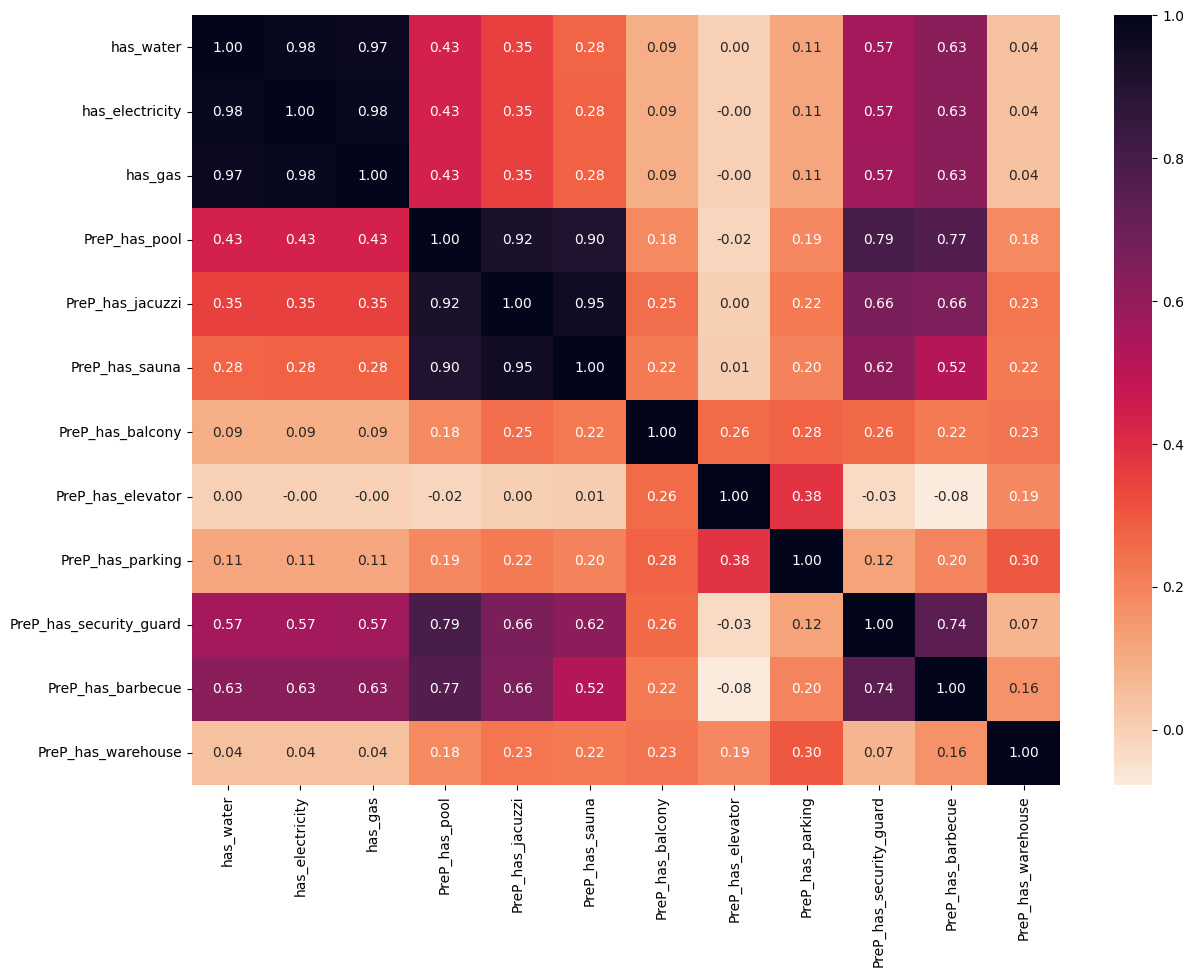

In [18]:
corr_matrix = PartK_TF.corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap= 'rocket_r',
    fmt='.2f'
)

plt.show()

<div dir="rtl">
با توجه به اینکه آب و برق و گاز، هر سه، درصد همبستگی بسیار بالایی دارن، پس میتونیم یه ستون تکی با عنوان <span dir="ltr">has_utilities</span> بسازیم که نماینده‌ی هر سه ستون باشه!

همینطور برای ستون‌های استخر، سونا و جکوزی هم این رابطه‌ی بسیار نزدیک وجود داره؛ پس میتونیم یه ستون تکی دیگه با عنوان <span dir="ltr">has_wellness_facilities</span> اینبار برای نمایندگی این سه ستون در نظر بگیریم.
</div>

<div dir="rtl">

توی این بخش مجبوریم تایپ مقادیر رو <span dir="ltr">boolean</span> کنیم تا با انجام اعمال منطقی، دیتامون دچار مقدار <span dir="ltr">False</span> اشتباهی نشه!

</div>

```
e = [True, NaN,  NaN,  False]
w = [NaN,  NaN,  True, NaN]
g = [NaN,  NaN,  NaN,  NaN]
e | w | g = [True, <NA>, True, <NA>]
```


In [19]:
cols_util = ['has_electricity', 'has_water', 'has_gas']
cols_well = ['PreP_has_pool', 'PreP_has_jacuzzi', 'PreP_has_sauna']

for col in cols_util + cols_well:
    PartK_TF[col] = PartK_TF[col].astype('boolean') 

PartK_TF['has_utilities'] = PartK_TF['has_electricity'] | PartK_TF['has_water'] | PartK_TF['has_gas']
PartK_TF['has_wellness_facilities'] = PartK_TF['PreP_has_pool'] | PartK_TF['PreP_has_jacuzzi'] | PartK_TF['PreP_has_sauna']

<div dir="rtl">
به طور معمول، اگه خونه‌ای دارای آسانسور باشه، به معنی این هست که برق هم داره. 
اگه باربیکیو داشته باشه، به این معنی هست که گاز هم داره. 
همچنین اگه استخر، سونا و یا جکوزی داشته باشه، انتظار میره که آب هم داشته باشه.
همه این‌ها فرض قطعی نیستن ولی فرض منطقی هستن و ما سعی میکنیم با این فرض منطقی، مقادیر <span dir="ltr">missing value</span> رو با دقت پر کنیم.
</div>

In [20]:
cols = [
    'PreP_has_elevator',
    'PreP_has_barbecue',
    'PreP_has_pool',
    'PreP_has_jacuzzi',
    'PreP_has_sauna'
]

mask = (
    PartK_TF[cols].eq(True).any(axis=1)
    & PartK_TF['has_utilities'].isna()
)

PartK_TF.loc[mask, 'has_utilities'] = True
PartK_TF

,has_water,has_electricity,has_gas,PreP_has_pool,PreP_has_jacuzzi,PreP_has_sauna,PreP_has_balcony,PreP_has_elevator,PreP_has_parking,PreP_has_security_guard,PreP_has_barbecue,PreP_has_warehouse,has_utilities,has_wellness_facilities
0,<NA>,<NA>,<NA>,True,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,True,True
1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
3,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,False,True,<NA>
4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,True,True,NaN,NaN,True,True,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
999996,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
999997,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,NaN,True,NaN,NaN,True,<NA>,<NA>
999998,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>


In [21]:
nan_report = pd.DataFrame({
    'column': PartK_TF.columns,
    'nan_count': PartK_TF.isna().sum(),
    'nan_percent': PartK_TF.isna().mean() * 100
}).sort_values('nan_percent', ascending=False)

nan_report

,column,nan_count,nan_percent
has_gas,has_gas,966570,96.6570
has_water,has_water,966556,96.6556
has_electricity,has_electricity,966555,96.6555
PreP_has_barbecue,PreP_has_barbecue,961975,96.1975
PreP_has_sauna,PreP_has_sauna,961592,96.1592
PreP_has_jacuzzi,PreP_has_jacuzzi,956928,95.6928
PreP_has_pool,PreP_has_pool,936894,93.6894
PreP_has_security_guard,PreP_has_security_guard,932840,93.2840
has_wellness_facilities,has_wellness_facilities,932188,93.2188
has_utilities,has_utilities,570312,57.0312


In [22]:
cols = PartK_TF.columns
PartK[cols] = PartK_TF[cols].astype(object)
PartK.replace('unselect', np.nan, inplace=True)
PartK

,PreP_has_warm_water_provider,PreP_has_heating_system,PreP_has_restroom,floor_material,building_direction,PreP_has_cooling_system,has_water,has_electricity,has_gas,PreP_has_pool,PreP_has_jacuzzi,PreP_has_sauna,PreP_has_balcony,PreP_has_elevator,PreP_has_parking,PreP_has_security_guard,PreP_has_barbecue,PreP_has_warehouse,has_utilities,has_wellness_facilities
0,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,True,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,True,True
1,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
2,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
3,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,False,True,<NA>
4,package,shoofaj,squat_seat,ceramic,north,air_conditioner,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,True,True,NaN,NaN,True,True,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
999996,NaN,NaN,seat,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,True,True,NaN,NaN,True,True,<NA>
999997,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,NaN,True,NaN,NaN,True,<NA>,<NA>
999998,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>


In [23]:
PartK.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   PreP_has_warm_water_provider  405309 non-null  object
 1   PreP_has_heating_system       381326 non-null  object
 2   PreP_has_restroom             423227 non-null  object
 3   floor_material                404317 non-null  object
 4   building_direction            320716 non-null  object
 5   PreP_has_cooling_system       364075 non-null  object
 6   has_water                     33444 non-null   object
 7   has_electricity               33445 non-null   object
 8   has_gas                       33430 non-null   object
 9   PreP_has_pool                 63106 non-null   object
 10  PreP_has_jacuzzi              43072 non-null   object
 11  PreP_has_sauna                38408 non-null   object
 12  PreP_has_balcony              533257 non-null  object
 13